# 1. Algorithm Explanation

**Support Vector Machine (SVM)**

Support Vector Machine (SVM) is a supervised machine learning algorithm primarily used for classification, although it can also be adapted for regression tasks. It is designed to classify data by identifying the optimal boundary that separates different classes with the largest possible margin, leading to strong predictive performance and good generalization.


---


**What is the algorithm?**

SVM is a classification algorithm that learns the relationship between input features and class labels by constructing an optimal decision boundary, known as a hyperplane. The objective is to maximize the margin, which is the distance between the hyperplane and the closest training samples from each class. These closest samples are called support vectors because they define the position of the decision boundary.

For datasets that cannot be separated using a straight line, SVM applies kernel functions to transform the data into a higher-dimensional feature space where a separating boundary can be found. Common kernels include the Linear, Polynomial, Radial Basis Function (RBF), and Sigmoid kernels.


---


**How does the algorithm work?**

Support Vector Machine (SVM) works by finding the optimal decision boundary (hyperplane) that separates data points from different classes while maximizing the margin, which is the distance between the hyperplane and the closest data points from each class. A larger margin generally leads to better generalization and reduces the risk of overfitting.

*The algorithm works through the following steps:*

1-*Represent the data:*

 Each training example is plotted as a point in an n-dimensional feature space, where each feature corresponds to one dimension.

2- *Find the optimal hyperplane:*

 SVM searches for the hyperplane that best separates the classes while maximizing the margin. Unlike many classification algorithms, SVM does not simply look for any separating boundary—it finds the one with the greatest possible distance from the nearest data points of each class.

3- *Identify the support vectors:*

The data points closest to the hyperplane are called support vectors. These points are the most critical because they define the location and orientation of the decision boundary. Removing or changing these points can significantly alter the hyperplane, while points farther away have little or no influence.

4- *Handle non-linearly separable data:*

 If the classes cannot be separated by a straight line, SVM uses the kernel trick. A kernel function maps the original data into a higher-dimensional feature space where the classes become linearly separable. Common kernels include:

* Linear Kernel: Used when the data is already linearly separable.
* Polynomial Kernel: Creates curved decision boundaries by considering polynomial relationships.
* Radial Basis Function (RBF) Kernel: The most commonly used kernel; handles complex nonlinear patterns by measuring similarity between data points.
* Sigmoid Kernel: Similar to activation functions used in neural networks, though it is less commonly used.

5- *Control classification errors (Soft Margin):*

 Real-world datasets often contain noise or overlapping classes. Instead of requiring perfect separation, SVM introduces a soft margin, controlled by the regularization parameter C.

* A large C prioritizes correctly classifying the training data, resulting in a narrower margin and a higher risk of overfitting.

* A small C allows some misclassifications, producing a wider margin and often better generalization to unseen data.

6 - *Make predictions:*

Once the optimal hyperplane has been learned, the trained SVM classifies new data points by determining which side of the hyperplane they fall on. The predicted class is based on the side of the decision boundary where the new observation lies.


---



**When should Support Vector Machine (SVM) be used?**
* Small to medium-sized datasets: SVM performs well when the dataset is not extremely large, as training becomes computationally expensive with millions of samples.

* High-dimensional data: It is particularly effective when the number of features is large compared to the number of observations, such as in text classification, image recognition, or gene expression analysis.

* Clearly separable classes: When the classes have distinct boundaries, SVM can find an optimal decision boundary with high classification accuracy.

* Nonlinear classification problems: If the data cannot be separated by a straight line, SVM can use kernel functions to model complex decision boundaries.

* When high prediction accuracy is required: SVM often provides strong generalization performance by maximizing the margin between classes, making it less prone to overfitting than some other algorithms.


---

**Advantages**

* High Accuracy: SVM often achieves excellent classification performance, especially on high-dimensional datasets.

* Effective in High-Dimensional Spaces: Performs well even when the number of features is greater than the number of samples.

* Robust to Overfitting: By maximizing the margin, SVM generalizes well to unseen data, particularly when properly regularized.

* Kernel Flexibility: Supports different kernel functions (Linear, Polynomial, RBF, Sigmoid), allowing it to model both linear and nonlinear decision boundaries.

* Memory Efficient: Only the support vectors are needed to define the decision boundary, making the model relatively memory-efficient after training.

**Limitations**

* Slow Training on Large Datasets: Training time increases significantly as the dataset size grows, making SVM less suitable for very large datasets.

* Parameter Tuning Required: Performance depends heavily on selecting the appropriate kernel and tuning hyperparameters such as C, gamma, and kernel-specific settings.

* Sensitive to Overlapping Classes: When classes overlap significantly or contain substantial noise, SVM performance may decrease.

* Limited Interpretability: Compared to algorithms like Decision Trees or Logistic Regression, SVM models are more difficult to interpret.

* Higher Computational Cost: Kernel-based SVMs can require substantial computational resources for complex or large-scale problems.

## Data

- The data we are working on is about if the costumers satisfied of the airlines services or not and we will try to predict the satisfaction of the customer

#2. Exploratory Data Analysis (EDA)

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)
from sklearn.svm import SVC
sns.set_style('whitegrid')

In [2]:
df = pd.read_csv('train.csv')
df.head()

,Unnamed: 0,id,Gender,Customer Type,Age,Type of Travel,Class,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,...,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes,satisfaction
0,0,70172,Male,Loyal Customer,13,Personal Travel,Eco Plus,460,3,4,...,5,4,3,4,4,5,5,25,18.0,neutral or dissatisfied
1,1,5047,Male,disloyal Customer,25,Business travel,Business,235,3,2,...,1,1,5,3,1,4,1,1,6.0,neutral or dissatisfied
2,2,110028,Female,Loyal Customer,26,Business travel,Business,1142,2,2,...,5,4,3,4,4,4,5,0,0.0,satisfied
3,3,24026,Female,Loyal Customer,25,Business travel,Business,562,2,5,...,2,2,5,3,1,4,2,11,9.0,neutral or dissatisfied
4,4,119299,Male,Loyal Customer,61,Business travel,Business,214,3,3,...,3,3,4,4,3,3,3,0,0.0,satisfied


In [ ]:
row , column = df.shape
print(f'There are {row} rows and {column} columns')

There are 103904 rows and 25 columns


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 103904 entries, 0 to 103903
Data columns (total 25 columns):
 #   Column                             Non-Null Count   Dtype  
---  ------                             --------------   -----  
 0   Unnamed: 0                         103904 non-null  int64  
 1   id                                 103904 non-null  int64  
 2   Gender                             103904 non-null  object 
 3   Customer Type                      103904 non-null  object 
 4   Age                                103904 non-null  int64  
 5   Type of Travel                     103904 non-null  object 
 6   Class                              103904 non-null  object 
 7   Flight Distance                    103904 non-null  int64  
 8   Inflight wifi service              103904 non-null  int64  
 9   Departure/Arrival time convenient  103904 non-null  int64  
 10  Ease of Online booking             103904 non-null  int64  
 11  Gate location                      1039

In [ ]:
df.describe()

,Unnamed: 0,id,Age,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,Ease of Online booking,Gate location,Food and drink,Online boarding,Seat comfort,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes
count,103904.000000,103904.000000,103904.000000,103904.000000,103904.000000,103904.000000,103904.000000,103904.000000,103904.000000,103904.000000,103904.000000,103904.000000,103904.000000,103904.000000,103904.000000,103904.000000,103904.000000,103904.000000,103904.000000,103594.000000
mean,51951.500000,64924.210502,39.379706,1189.448375,2.729683,3.060296,2.756901,2.976883,3.202129,3.250375,3.439396,3.358158,3.382363,3.351055,3.631833,3.304290,3.640428,3.286351,14.815618,15.178678
std,29994.645522,37463.812252,15.114964,997.147281,1.327829,1.525075,1.398929,1.277621,1.329533,1.349509,1.319088,1.332991,1.288354,1.315605,1.180903,1.265396,1.175663,1.312273,38.230901,38.698682
min,0.000000,1.000000,7.000000,31.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,25975.750000,32533.750000,27.000000,414.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,3.000000,3.000000,3.000000,2.000000,0.000000,0.000000
50%,51951.500000,64856.500000,40.000000,843.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,4.000000,4.000000,4.000000,4.000000,4.000000,3.000000,4.000000,3.000000,0.000000,0.000000
75%,77927.250000,97368.250000,51.000000,1743.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,5.000000,4.000000,4.000000,4.000000,5.000000,4.000000,5.000000,4.000000,12.000000,13.000000
max,103903.000000,129880.000000,85.000000,4983.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,1592.000000,1584.000000


In [ ]:
df.isnull().sum()

,0
Unnamed: 0,0
id,0
Gender,0
Customer Type,0
Age,0
Type of Travel,0
Class,0
Flight Distance,0
Inflight wifi service,0
Departure/Arrival time convenient,0


- there is missing values in the arrival delay only

In [ ]:
df.duplicated().sum()

np.int64(0)

- there is no duplicates

In [ ]:
df['satisfaction'].value_counts()

,count
satisfaction,
neutral or dissatisfied,58879
satisfied,45025


In [ ]:
m = {'neutral or dissatisfied':0 , 'satisfied':1}
df['satisfaction'] = df['satisfaction'].map(m)

In [ ]:
df['satisfaction'].value_counts()

,count
satisfaction,
0,58879
1,45025


- The target calss is nearly balanced i don't think we will face imbalanement problems

In [ ]:
df_sampled = df.sample(n=20000, random_state=42).reset_index(drop=True)

- We are taking a sample because the dataset is big

## 2.1 Univariant

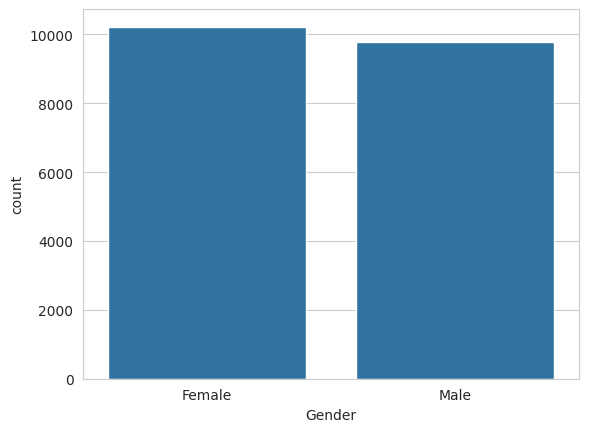

In [ ]:
sns.countplot(data=df_sampled, x='Gender')
plt.show()

- The gender is nearly balanced but the females are a bit more

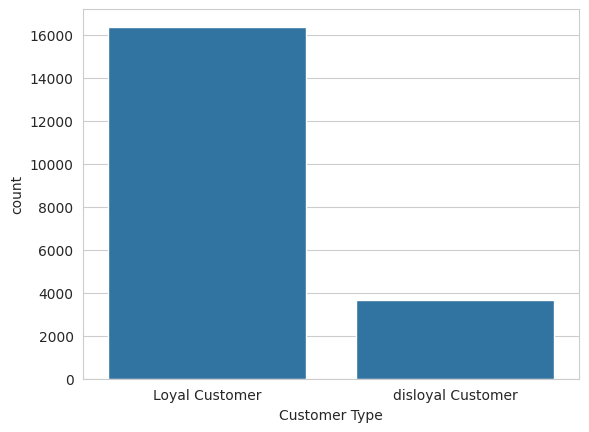

In [ ]:
sns.countplot(data=df_sampled, x='Customer Type')
plt.show()

- Most of the customers are loyal customers

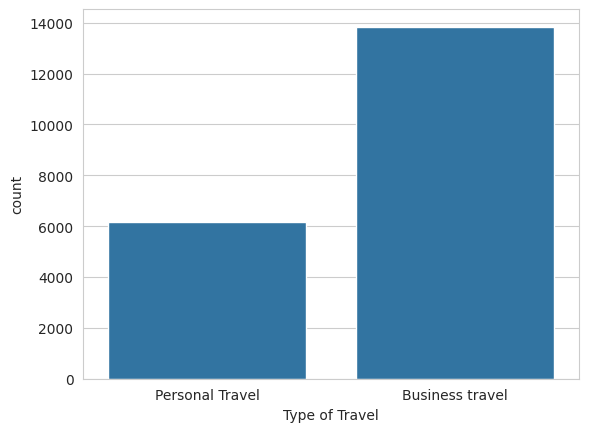

In [ ]:
sns.countplot(data=df_sampled, x='Type of Travel')
plt.show()

- Most travellers are travling for business and they are nearly double the personal travellers

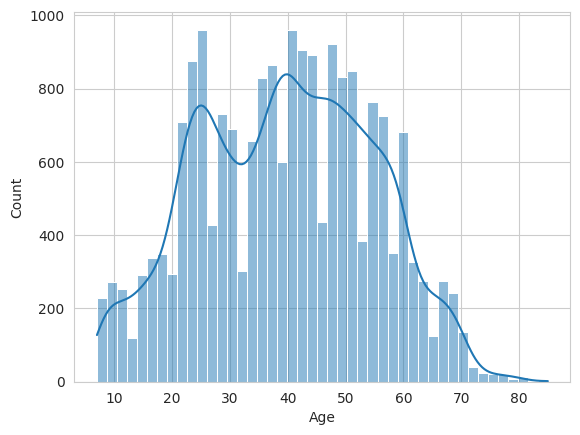

In [ ]:
sns.histplot(data=df_sampled, x='Age', kde=True)
plt.show()

- The ages are distriputed but most of them are between 21-60

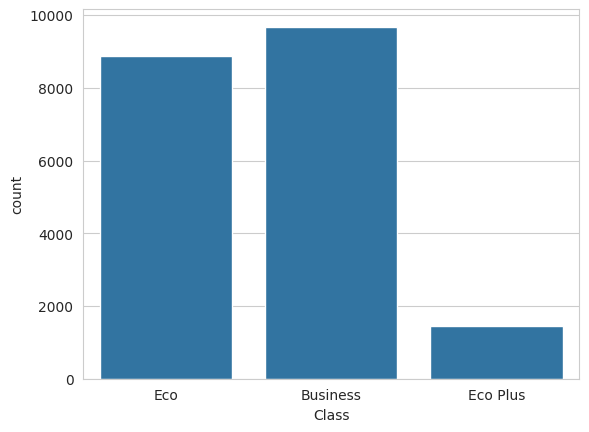

In [ ]:
sns.countplot(data=df_sampled, x='Class')
plt.show()

- The number of business and eco is near no each other but only few people pick eco plus

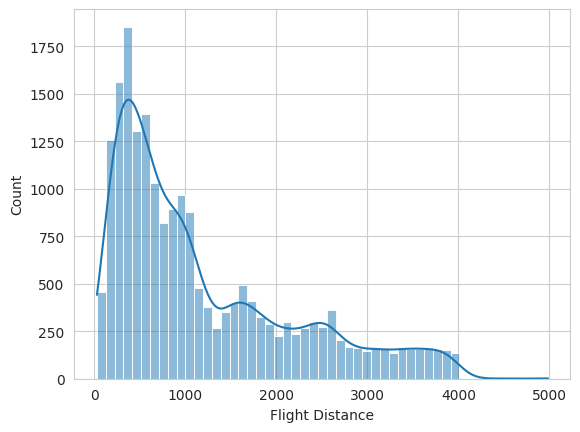

In [ ]:
sns.histplot(data=df_sampled, x='Flight Distance', kde=True)
plt.show()

- Most flights are between 200 - 1200

##2.2 Multivariant

Text(0.5, 1.0, 'Correlation Heatmap')

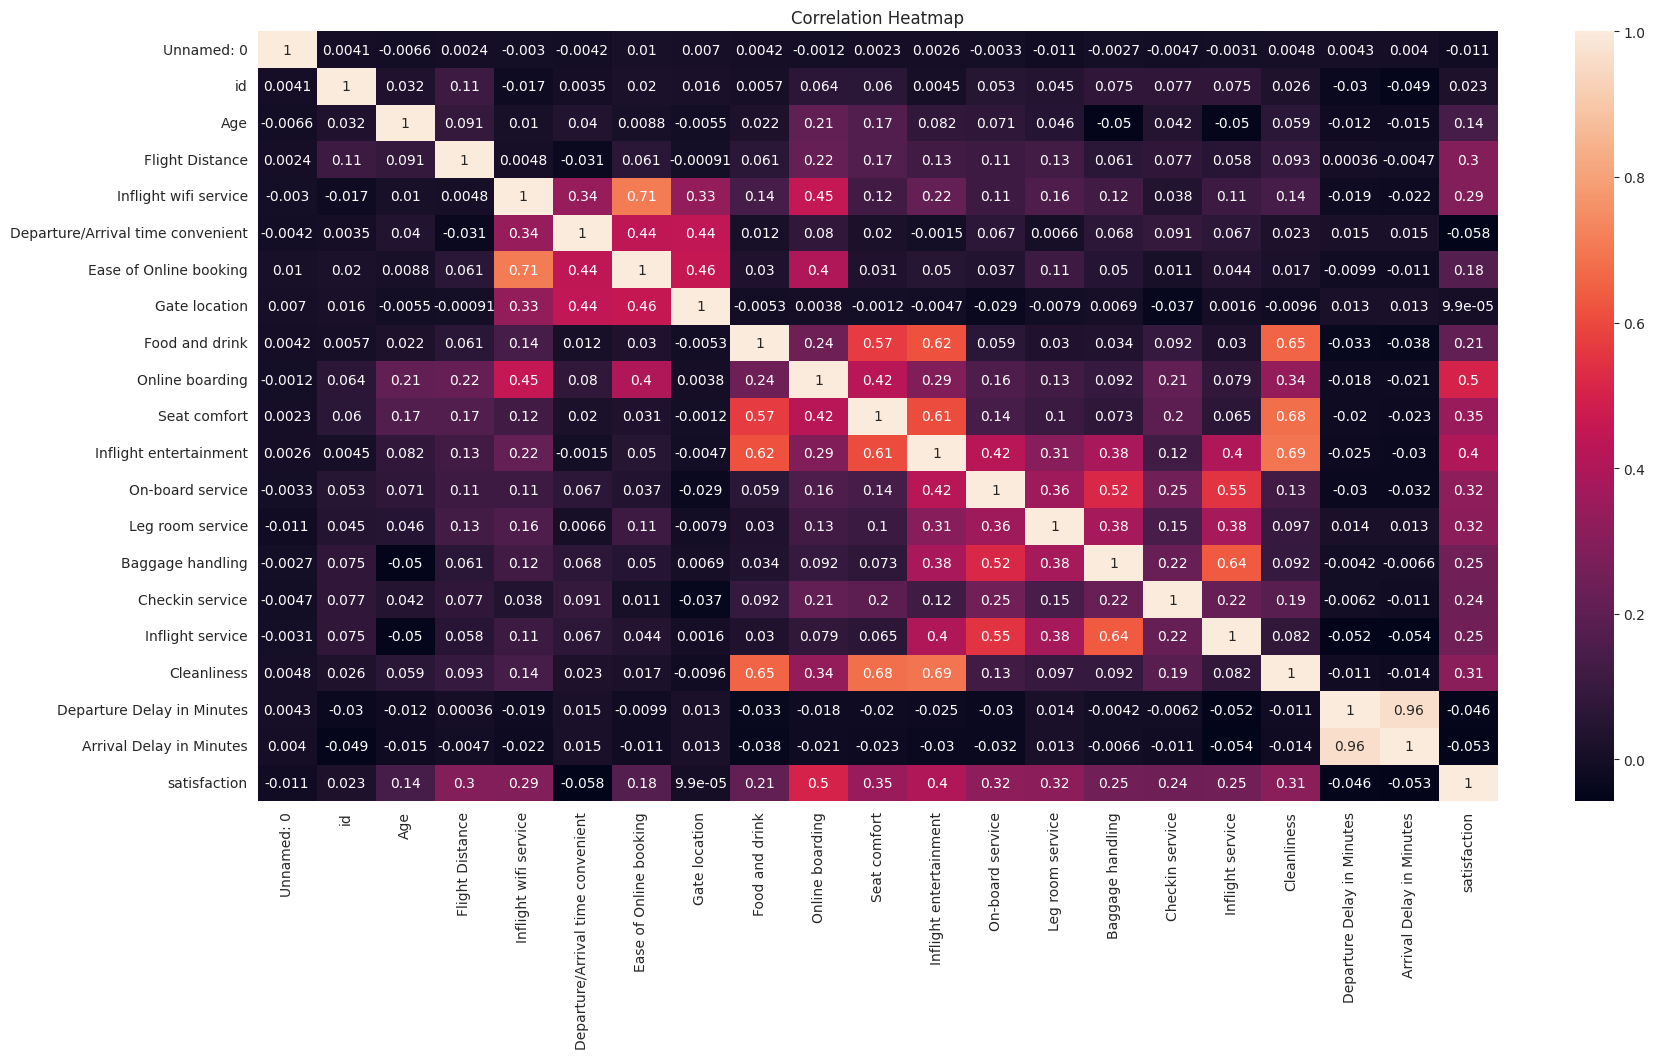

In [ ]:
corrlation = df_sampled.corr(numeric_only=True)
plt.figure(figsize=(20, 10))
sns.heatmap(corrlation, annot=True)
plt.title('Correlation Heatmap')

- We will take the strong correlations with the target (>0.29) and check the relationships:
1. online boarding
2. inflight entertainment
3. seat comfort
4. on-board servises
5. leg room services
6. cleanliness
7. flight distance
8. inflight wifi services



- we noticed a very strong correlation between arrival delay in minutes and departure delay in minutes which means that they are strongly reling on each other

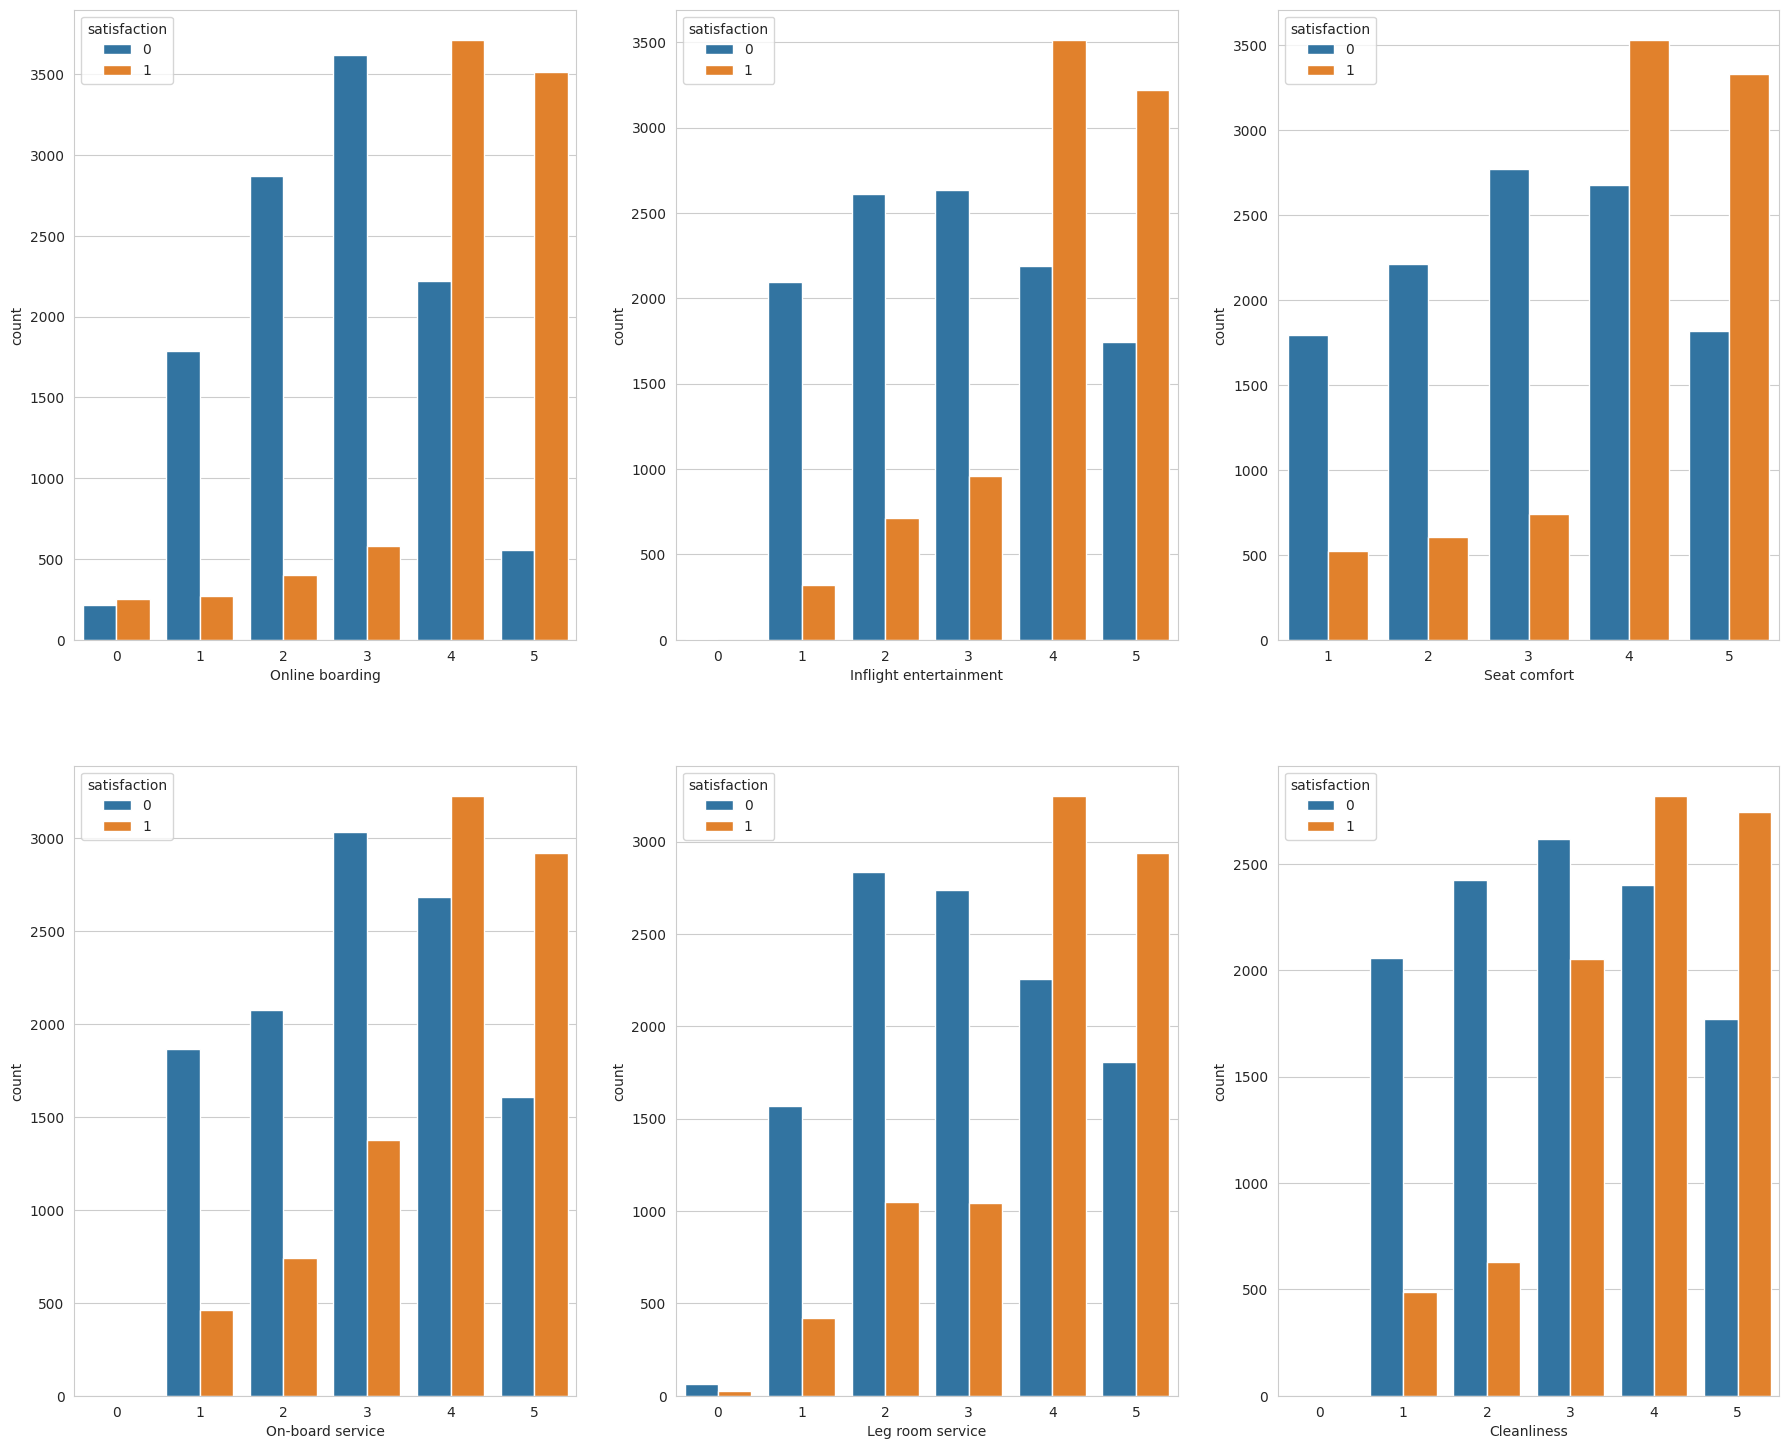

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(22, 18))

features = [
    'Online boarding', 'Inflight entertainment', 'Seat comfort',
    'On-board service', 'Leg room service', 'Cleanliness']

for i, feature in enumerate(features):
    row = i // 3
    col = i % 3
    sns.countplot(data=df_sampled, x=feature, hue='satisfaction', ax=axes[row, col])

- The number between 0-1 represents the satisfication level of the service

- As we can see these services are really related to the costumers satisfaction if the rating of the service is 5 we can see that the satisfaction level comes high too

<Axes: xlabel='satisfaction', ylabel='Flight Distance'>

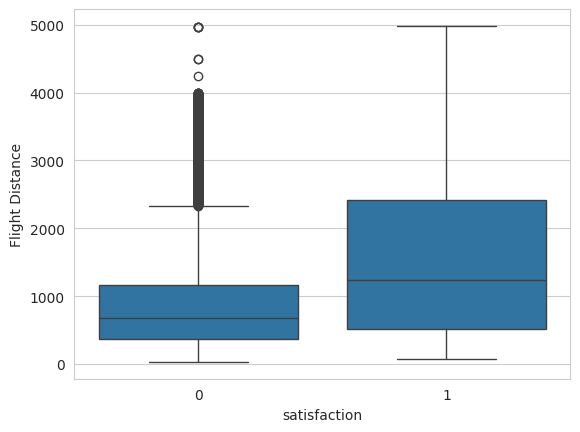

In [ ]:
sns.boxplot(data=df_sampled, x='satisfaction', y='Flight Distance')

- As shown in the figure , we can see that the satisfaction rate is distriputed across filghts distance but most of them are above 1300 , for the unsatisfied most of them are below 1200 which might indicate that if the distance is less the costumers needs more services because there is no time to sleep or doing anything

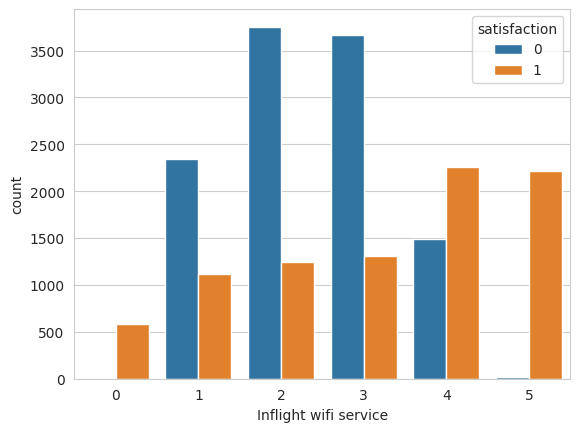

In [ ]:
sns.countplot(data=df_sampled, x='Inflight wifi service', hue='satisfaction')
plt.show()

- We can see that providing inflight wifi could really effect the satisfaction when the rating is 5 nearly all the costumers were satisfied !

# 3.Data Preprocessing

In [3]:
#checking null
df.isnull().sum()
(df.isnull().sum()/len(df))*100
df["Arrival Delay in Minutes"] = df["Arrival Delay in Minutes"].fillna(
    df["Arrival Delay in Minutes"].median()
)


In [4]:
df.duplicated().sum()

np.int64(0)

In [5]:
#Remove Unnecessary Columns
df.drop(columns=["Unnamed: 0", "id"], inplace=True)
df.dtypes

,0
Gender,object
Customer Type,object
Age,int64
Type of Travel,object
Class,object
Flight Distance,int64
Inflight wifi service,int64
Departure/Arrival time convenient,int64
Ease of Online booking,int64
Gate location,int64


In [6]:
# encode Categorical Variables
le = LabelEncoder()

categorical_columns = [
    "Gender",
    "Customer Type",
    "Type of Travel",
    "Class",
    "satisfaction"
]

for col in categorical_columns:
    df[col] = le.fit_transform(df[col])

For SVM, using LabelEncoder is acceptable here because these categorical variables have a small number of categories. One-hot encoding is another valid option, but label encoding is commonly used for this dataset.

In [7]:
scaler = StandardScaler()
X = df.drop("satisfaction", axis=1)
y = df["satisfaction"]


X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
print(X_train_scaled)

[[-0.98558326 -0.47338059  0.5027936  ... -0.21831464 -0.38663564
  -0.3913212 ]
 [ 1.01462762  2.11246516 -0.29046419 ... -0.21831464 -0.38663564
  -0.3913212 ]
 [-0.98558326 -0.47338059  1.75878511 ...  1.30478479  1.64072308
   1.71756481]
 ...
 [ 1.01462762 -0.47338059  1.03163213 ...  1.30478479 -0.38663564
  -0.3913212 ]
 [ 1.01462762  2.11246516 -0.42267383 ... -1.74141408  0.2891506
   0.38022246]
 [ 1.01462762  2.11246516 -1.28203644 ... -1.74141408  0.67902728
   0.02016875]]


#4. Model implementation

In [8]:
svm_model = SVC( kernel='rbf',C=1, gamma='scale')
svm_model.fit(X_train_scaled, y_train)

SVC(C=1)

#5. Model evaluation

In [9]:
y_pred = svm_model.predict(X_test_scaled)

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted')
recall = recall_score(y_test, y_pred, average='weighted')
f1 = f1_score(y_test, y_pred, average='weighted')
cm = confusion_matrix(y_test, y_pred)

print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1 Score : {f1:.4f}")
print("\nConfusion Matrix:")
print(cm)

Accuracy : 0.9545
Precision: 0.9545
Recall   : 0.9545
F1 Score : 0.9545

Confusion Matrix:
[[11389   387]
 [  558  8447]]


#Bonus

## Tune hyperparameters & Improve model performance

In [10]:
svm_model2 = SVC( kernel='rbf',C=10, gamma='scale')
svm_model2.fit(X_train_scaled, y_train)

SVC(C=10)

In [11]:
y_pred2 = svm_model2.predict(X_test_scaled)

accuracy = accuracy_score(y_test, y_pred2)
precision = precision_score(y_test, y_pred2, average='weighted')
recall = recall_score(y_test, y_pred2, average='weighted')
f1 = f1_score(y_test, y_pred2, average='weighted')
cm = confusion_matrix(y_test, y_pred2)

print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1 Score : {f1:.4f}")
print("\nConfusion Matrix:")
print(cm)

Accuracy : 0.9595
Precision: 0.9596
Recall   : 0.9595
F1 Score : 0.9595

Confusion Matrix:
[[11458   318]
 [  523  8482]]


| Metric    |    model1 |        model2 | Improve |
| --------- | -----: | ---------: | -----: |
| Accuracy  | 95.45% | **95.95%** | +0.50% |
| Precision | 95.45% | **95.96%** | +0.51% |
| Recall    | 95.45% | **95.95%** | +0.50% |
| F1 Score  | 95.45% | **95.95%** | +0.50% |


## Compare their algorithm with another classification model


In [12]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(n_estimators=100,random_state=42)
rf_model.fit(X_train_scaled, y_train)

RandomForestClassifier(random_state=42)

In [13]:
y_pred_rf = rf_model.predict(X_test_scaled)

print("Accuracy :", accuracy_score(y_test, y_pred_rf))
print("Precision:", precision_score(y_test, y_pred_rf, average='weighted'))
print("Recall   :", recall_score(y_test, y_pred_rf, average='weighted'))
print("F1 Score :", f1_score(y_test, y_pred_rf, average='weighted'))
print(confusion_matrix(y_test, y_pred_rf))

Accuracy : 0.9623694721139503
Precision: 0.9625133935271156
Recall   : 0.9623694721139503
F1 Score : 0.9623034074084595
[[11508   268]
 [  514  8491]]


| Model             |   Accuracy |  Precision |     Recall |   F1 Score |
| ----------------- | ---------: | ---------: | ---------: | ---------: |
| SVM (Default)     |     95.45% |     95.45% |     95.45% |     95.45% |
| SVM (Tuned)       |     95.95% |     95.96% |     95.95% |     95.95% |
| **Random Forest** | **96.24%** | **96.25%** | **96.24%** | **96.23%** |
